In [1]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import rasterio.mask as rio_mask

In [2]:
data_path = Path(os.environ["DATA_PATH"])

In [3]:
bounds = (
    gpd.read_file(data_path / "lim_aumxl24").to_crs("EPSG:32611")["geometry"].item()
)

In [4]:
with rio.open(data_path / "LST" / "01 MXL_LSTdia_202104191.tif") as ds:
    data_day = ds.read(1)
    data_day[data_day == ds.nodata] = np.nan

    transform_day = ds.transform

    data_day_masked, transform_day_masked = rio_mask.mask(
        ds,
        [bounds],
        crop=True,
        nodata=ds.nodata,
    )
    data_day_masked[data_day_masked == ds.nodata] = np.nan
    data_day_masked = data_day_masked.squeeze()

with rio.open(data_path / "LST" / "01 MXL_LSTnoche_20210418.tif") as ds:
    data_night = ds.read(1)
    data_night[data_night == ds.nodata] = np.nan

    data_night_masked, _ = rio_mask.mask(
        ds,
        [bounds],
        crop=True,
        nodata=ds.nodata,
    )
    data_night_masked[data_night_masked == ds.nodata] = np.nan
    data_night_masked = data_night_masked.squeeze()

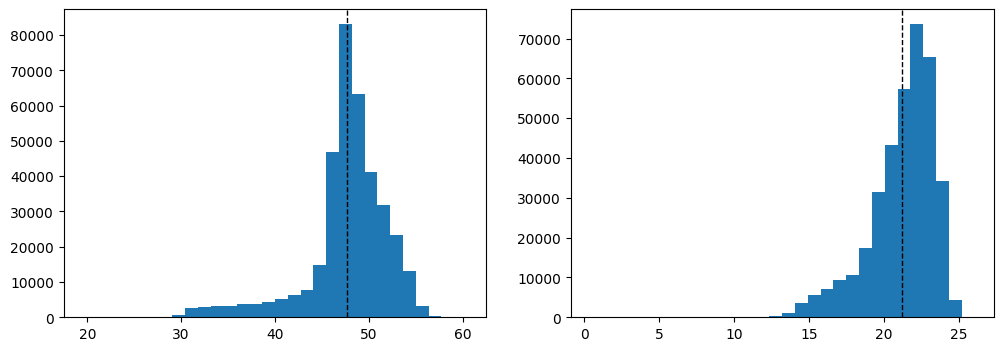

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(data_day_masked.flatten(), bins=30)
ax1.axvline(np.nanmean(data_day_masked), color="k", linestyle="dashed", linewidth=1)

ax2.hist(data_night_masked.flatten(), bins=30)
ax2.axvline(np.nanmean(data_night_masked), color="k", linestyle="dashed", linewidth=1)

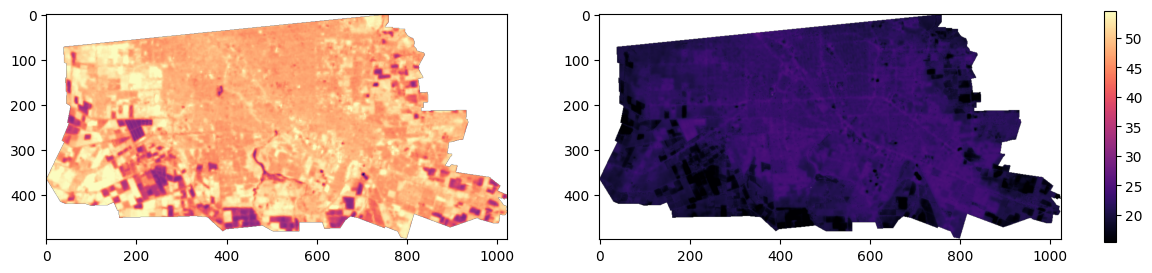

In [6]:
vmin = min(np.nanpercentile(data_day_masked, 2), np.nanpercentile(data_night_masked, 2))
vmax = max(
    np.nanpercentile(data_day_masked, 98),
    np.nanpercentile(data_night_masked, 98),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3))
im0 = ax1.imshow(data_day_masked, cmap="magma", vmin=vmin, vmax=vmax)
im1 = ax2.imshow(data_night_masked, cmap="magma", vmin=vmin, vmax=vmax)

# Add a single colorbar for both plots, vertical, to the right
cbar = fig.colorbar(
    im0,
    ax=[ax1, ax2],
    orientation="vertical",
    fraction=0.025,
    pad=0.04,
)

In [7]:
with rio.open(
    "./temp_day_night.tif",
    "w",
    count=2,
    height=data_day.shape[0],
    width=data_day.shape[1],
    driver="GTiff",
    crs="EPSG:32611",
    transform=transform_day,
    compress="ZSTD",
    dtype="float64",
) as dst:
    dst.write(data_day, 1)
    dst.write(data_night, 2)